# F_tau vs. FDC: real time series vs. BrainLM attention

Three related checks on the last-layer BrainLM attention for a handful of subjects,
running the model's forward pass directly (CPU) since the raw per-token attention
matrix isn't saved to disk by `run_model.py` -- only the already time/head-averaged
`[424, 424]` outputs are.

**Terminology, fixed here after an earlier mislabeling:**

- **F_tau**: the raw, *unaveraged* `[num_regions, num_regions]` submatrix of the full
  `[seq_len, seq_len]` last-layer attention matrix for one specific
  (source time patch, target time patch) pair -- literally element `[t_src, t_tgt]` of
  the `(num_patches x num_patches)` grid of 424x424 blocks the full matrix decomposes
  into. `postprocess.compute_ftau` (averaging that block over every valid `t`) is a
  *different*, aggregate quantity -- not this.
- **FDC** ("delay connectivity"): the aggregate, lag-`tau` matrix -- from real BOLD
  time series (variance-normalized, `tau`-lagged cross-covariance; `tau=0` is plain
  Pearson FC) or from attention (`compute_ftau`, averaging the `(t, t+tau)` block over
  every valid `t`). This is what the earlier "F_tau(tau=1)" plots actually were.
- **FCD** (functional connectivity dynamics, Hansen et al., 2015): a time x time matrix
  of correlations between windowed FC snapshots, capturing how FC *switches* over time
  rather than a single static/aggregate summary.
- The delay used throughout is **1 BrainLM time patch** (`timepoint_patching_size` TRs,
  20 TRs for the `old_13M` checkpoint) -- the smallest lag the model's own tokenization
  can express, i.e. the delay "equivalent to 1 window" of the model.

All F_tau/FDC analysis (static, aggregate quantities) comes first; FCD (the
time-resolved, dynamic quantity) comes last since it's conceptually a different kind of
object (time x time, not region x region):

1. Plot F_tau (the raw single-block definition) plus where it sits inside the full
   attention matrix.
2. Asymmetry `(A - A.T)/2` at 1-patch lag: F_tau (attention, raw) vs. FDC (real ts,
   aggregate) -- correlate the two directed-structure matrices.
3. FDC at zero lag: real ts (Pearson FC) vs. attention's same-time ("diagonal") blocks.
4. FCD: real ts (10 per-patch windowed FC snapshots) vs. attention's 10 diagonal
   blocks -- correlate the two time x time matrices.

In [1]:
import os
import sys

MAX_CPU_THREADS = 4
os.environ["OMP_NUM_THREADS"] = str(MAX_CPU_THREADS)
os.environ["MKL_NUM_THREADS"] = str(MAX_CPU_THREADS)
os.environ["OPENBLAS_NUM_THREADS"] = str(MAX_CPU_THREADS)

import h5py
import numpy as np
import torch
import matplotlib.pyplot as plt

torch.set_num_threads(MAX_CPU_THREADS)

sys.path.insert(0, os.path.abspath(".."))
from run_model import load_brainlm_model, load_spatial_coordinates
from postprocess import compute_ftau

# run_model imports visualize_attention, which calls matplotlib.use("Agg") for
# headless script runs -- re-enable the inline backend for this notebook.
get_ipython().run_line_magic("matplotlib", "inline")

INPUT_H5 = "../data/input/fmri_timeseries_subset_100.h5"
COORDS = "../data/input/toolkit/atlases/A424_Coordinates.dat"
HF_REPO = "vandijklab/brainlm"
SUBFOLDER = "old_13M"

WINDOW_SIZE = 200
TAU_PATCHES = 1     # "delay equivalent to 1 window" = 1 BrainLM time patch

N_SUBJECTS = 25
RANDOM_SEED = 0

FIGURES_DIR = "figures"
OUTPUTS_DIR = "outputs"
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(OUTPUTS_DIR, exist_ok=True)

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

model, config = load_brainlm_model(HF_REPO, SUBFOLDER)
model.to(device)
spatial_coords_base = load_spatial_coordinates(COORDS)

num_regions = config.num_brain_voxels
num_patches = WINDOW_SIZE // config.timepoint_patching_size
seq_len = num_regions * num_patches
tau_trs = TAU_PATCHES * config.timepoint_patching_size
identity_noise = torch.arange(seq_len, dtype=torch.float32) / seq_len

print(f"num_regions={num_regions}, num_patches={num_patches}, seq_len={seq_len}, "
      f"tau={TAU_PATCHES} patch(es) = {tau_trs} TRs")

Device: cpu


/home/fmoss/miniforge3/envs/brainlm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/home/fmoss/miniforge3/envs/brainlm/lib/python3.10/site-packages/accelerate/utils/torch_xla.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


loading weights file pytorch_model.bin from cache at /home/fmoss/.cache/huggingface/hub/models--vandijklab--brainlm/snapshots/4c54e0cccf920d9d6af7c647cb866fc19c60cf26/old_13M/pytorch_model.bin


All model checkpoint weights were used when initializing BrainLMForPretraining.



All the weights of BrainLMForPretraining were initialized from the model checkpoint at vandijklab/brainlm.
If your task is similar to the task the model of the checkpoint was trained on, you can already use BrainLMForPretraining for predictions without further training.


num_regions=424, num_patches=10, seq_len=4240, tau=1 patch(es) = 20 TRs


In [3]:
with h5py.File(INPUT_H5, "r") as f:
    all_subject_ids = [s.decode("utf-8") for s in f["subject_ids"][:]]
    n_available = f["parcel_ts"].shape[0]

rng = np.random.default_rng(RANDOM_SEED)
# subject_indices = sorted(rng.choice(n_available, size=N_SUBJECTS, replace=False).tolist())

subject_indices = np.linspace(0, 24, 25).astype(int)
print("Subjects:", [all_subject_ids[i] for i in subject_indices])

Subjects: ['Sub_0000', 'Sub_0001', 'Sub_0002', 'Sub_0004', 'Sub_0005', 'Sub_0006', 'Sub_0007', 'Sub_0008', 'Sub_0009', 'Sub_0010', 'Sub_0011', 'Sub_0012', 'Sub_0013', 'Sub_0014', 'Sub_0015', 'Sub_0016', 'Sub_0017', 'Sub_0018', 'Sub_0019', 'Sub_0020', 'Sub_0021', 'Sub_0022', 'Sub_0023', 'Sub_0024', 'Sub_0025']


In [4]:
def robust_scale_regions(window_raw):
    """Per-region median/IQR scaling, same recipe as run_model.py's preprocess_subject_data,
    applied to a single [window_size, num_regions] window."""
    scaled = window_raw.T.copy()  # [num_regions, window_size]
    for r in range(scaled.shape[0]):
        v = scaled[r, :]
        median = np.median(v)
        q75, q25 = np.percentile(v, [75, 25])
        iqr = q75 - q25
        if iqr == 0:
            iqr = 1e-6
        scaled[r, :] = (v - median) / iqr
    return scaled


def compute_subject_attention(sub_idx):
    """Single window_size=200-TR window (TRs [0, WINDOW_SIZE)) last-layer attention
    (heads averaged, CLS dropped) for one subject, matching run_model.py's
    `attn_no_cls` exactly -- without going through preprocess_subject_data's
    multi-window stride math, which requires num_windows>=2 and (for num_windows=1)
    would silently select the *last* WINDOW_SIZE TRs instead of TRs [0, WINDOW_SIZE).
    Returns (subject_id, raw_ts [T, num_regions], attn_no_cls [seq_len, seq_len])."""
    with h5py.File(INPUT_H5, "r") as f:
        sub_id = f["subject_ids"][sub_idx].decode("utf-8")
        raw_ts = f["parcel_ts"][sub_idx, :, :]

    window_raw = raw_ts[:WINDOW_SIZE, :]  # TRs [0, WINDOW_SIZE)
    scaled = robust_scale_regions(window_raw)
    fmri_window = torch.tensor(scaled[None, ...], dtype=torch.float32).to(device)

    spatial_coords = spatial_coords_base.to(device)  # already batch=1
    noise = identity_noise.unsqueeze(0).to(device)   # [1, seq_len]

    with torch.no_grad():
        outputs = model.vit(
            signal_vectors=fmri_window,
            xyz_vectors=spatial_coords,
            noise=noise,
            output_attentions=True,
        )

    ids_restore = outputs.ids_restore.cpu().numpy()
    if not np.array_equal(ids_restore, np.broadcast_to(np.arange(seq_len), ids_restore.shape)):
        raise RuntimeError(f"{sub_id}: token order was shuffled (ids_restore != identity); refusing to reshape.")

    avg_attention = outputs.attentions[-1].mean(dim=1)[0]  # avg across heads; single window, TRs [0, WINDOW_SIZE)
    attn_no_cls = avg_attention[1:, 1:].cpu().numpy().astype("float32")
    return sub_id, raw_ts, attn_no_cls

In [5]:
subjects = []
for idx in subject_indices:
    sub_id, raw_ts, attn_no_cls = compute_subject_attention(idx)
    subjects.append({"subject_id": sub_id, "raw_ts": raw_ts, "attn_no_cls": attn_no_cls})
    print(f"{sub_id}: raw_ts={raw_ts.shape}, attn_no_cls={attn_no_cls.shape}")

Sub_0000: raw_ts=(1200, 424), attn_no_cls=(4240, 4240)


Sub_0001: raw_ts=(1200, 424), attn_no_cls=(4240, 4240)


Sub_0002: raw_ts=(1200, 424), attn_no_cls=(4240, 4240)


Sub_0004: raw_ts=(1200, 424), attn_no_cls=(4240, 4240)


Sub_0005: raw_ts=(1200, 424), attn_no_cls=(4240, 4240)


...

Sub_0021: raw_ts=(1200, 424), attn_no_cls=(4240, 4240)


Sub_0022: raw_ts=(1200, 424), attn_no_cls=(4240, 4240)


Sub_0023: raw_ts=(1200, 424), attn_no_cls=(4240, 4240)


Sub_0024: raw_ts=(1200, 424), attn_no_cls=(4240, 4240)


Sub_0025: raw_ts=(1200, 424), attn_no_cls=(4240, 4240)


## Part 1 -- F_tau: the raw submatrix, element [0, 1] of the full attention matrix

The full `[seq_len, seq_len]` last-layer attention decomposes into a
`(num_patches x num_patches)` grid of `[num_regions, num_regions]` blocks. F_tau is just
one of those blocks, picked out directly -- no averaging. With `T_SRC=0` and
`T_TGT=TAU_PATCHES=1` this is literally "element [0, 1]" of that grid.

Because BrainLM's native token order is region-major (`token i = region * num_patches +
time_patch`, see `postprocess.py`'s docstring), this block is *not* a contiguous square
in the raw `[seq_len, seq_len]` matrix -- its `num_regions^2` entries are scattered every
`num_patches`-th row/column. The left panel marks exactly those entries on top of the full
attention heatmap; the right panel is the same entries pulled out into their own
`[424, 424]` matrix.

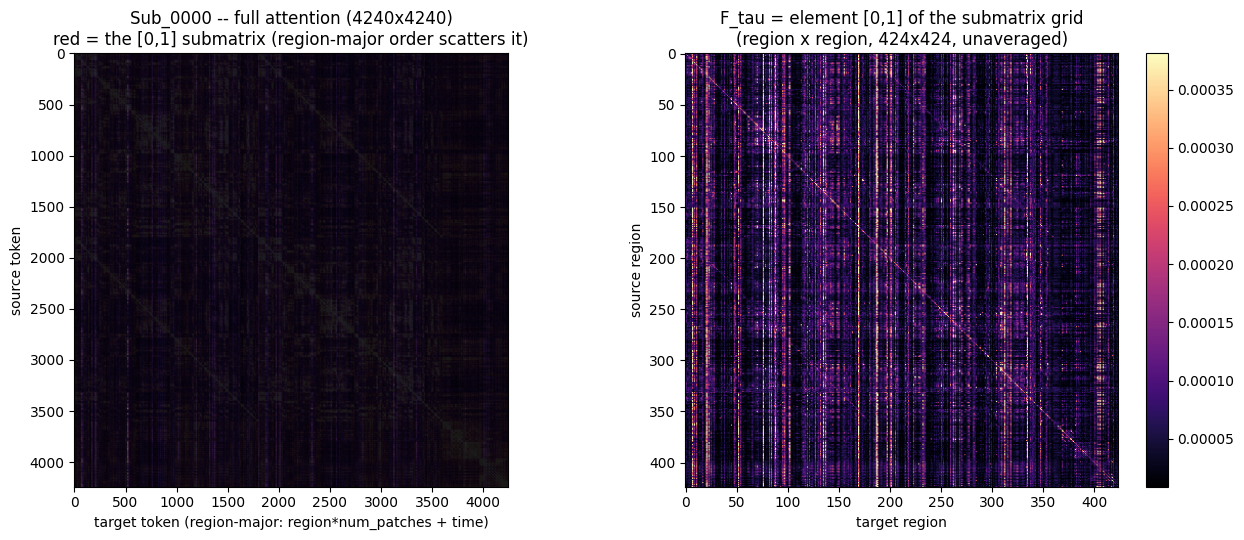

In [6]:
def raw_ftau_block(attn_no_cls, num_regions, num_patches, t_src, t_tgt):
    """The single, UNAVERAGED [num_regions, num_regions] submatrix of the full
    [seq_len, seq_len] attention matrix for one specific (source time patch, target
    time patch) pair. attn_no_cls must use BrainLM's native region-major token order
    (see postprocess.py's docstring)."""
    attn_4d = attn_no_cls.reshape(num_regions, num_patches, num_regions, num_patches)
    return attn_4d[:, t_src, :, t_tgt]

sub = subjects[0]
T_SRC, T_TGT = 0, 1  # "element [0, 1]" of the submatrix grid, for TAU_PATCHES=1

ftau_block = raw_ftau_block(sub["attn_no_cls"], num_regions, num_patches, T_SRC, T_TGT)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

full = sub["attn_no_cls"]
v_lo, v_hi = np.percentile(full, 1), np.percentile(full, 99)
axes[0].imshow(full, cmap="magma", vmin=v_lo, vmax=v_hi)

rows = np.arange(T_SRC, seq_len, num_patches)
cols = np.arange(T_TGT, seq_len, num_patches)
row_grid, col_grid = np.meshgrid(rows, cols, indexing="ij")
axes[0].scatter(col_grid.ravel(), row_grid.ravel(), s=0.3, marker="s", color="red", alpha=0.35, rasterized=True)
axes[0].set_title(f"{sub['subject_id']} -- full attention ({seq_len}x{seq_len})\n"
                   f"red = the [{T_SRC},{T_TGT}] submatrix (region-major order scatters it)")
axes[0].set_xlabel("target token (region-major: region*num_patches + time)")
axes[0].set_ylabel("source token")

v_lo2, v_hi2 = np.percentile(ftau_block, 1), np.percentile(ftau_block, 99)
im1 = axes[1].imshow(ftau_block, cmap="magma", vmin=v_lo2, vmax=v_hi2)
axes[1].set_title(f"F_tau = element [{T_SRC},{T_TGT}] of the submatrix grid\n(region x region, 424x424, unaveraged)")
axes[1].set_xlabel("target region")
axes[1].set_ylabel("source region")
fig.colorbar(im1, ax=axes[1], fraction=0.046)

fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "ftau_raw_submatrix.png"), dpi=130, bbox_inches="tight")
plt.show()

### All available lags from region 0, both directions

`num_patches=10`, so time-patch indices only run `0..9` -- `[0,10]` doesn't exist, the
last valid forward lag is `[0,9]`. Below: every forward block `[0,t]` (region 0's row at
time 0 attending to time `t`) and every backward block `[t,0]` (time `t` attending back to
time 0), `t=1..9`, sharing one color scale so magnitudes are directly comparable across
lags and direction.

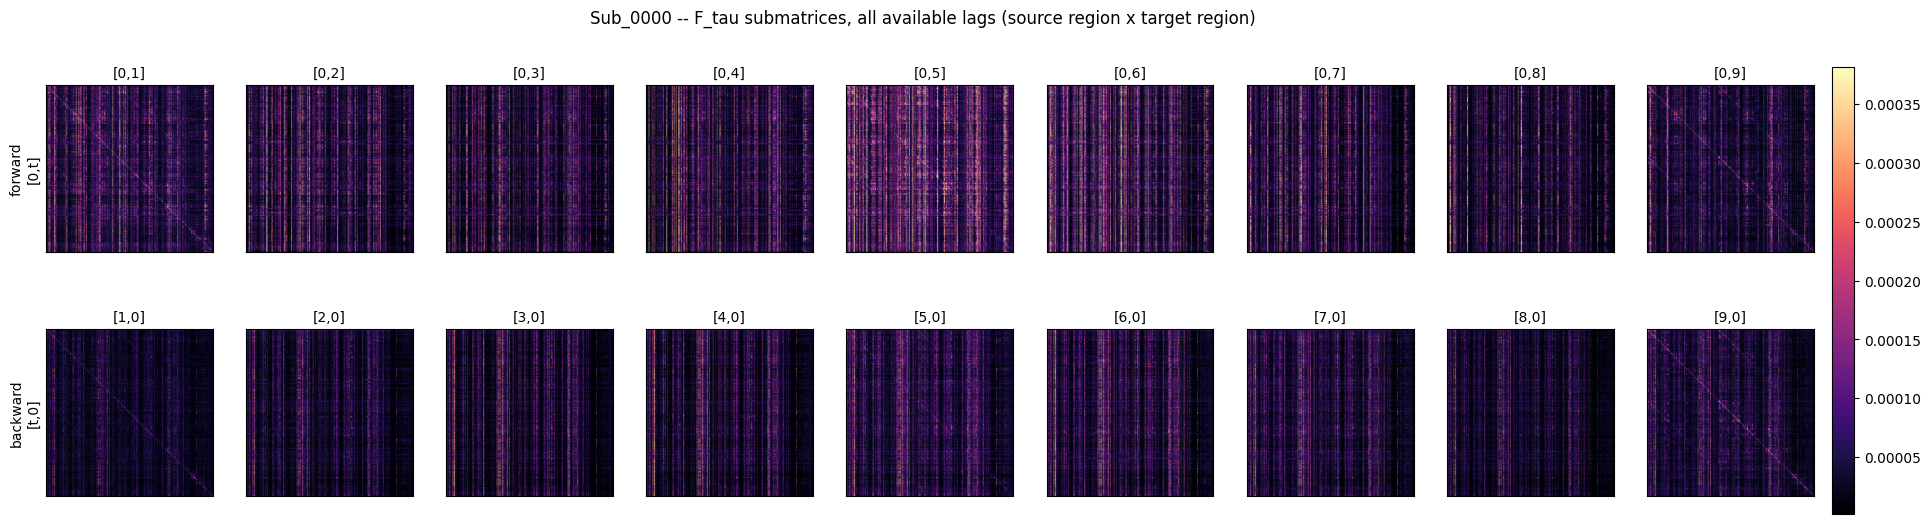

In [7]:
taus = list(range(1, num_patches))  # 1..9 -- the only valid lags when num_patches=10
forward_blocks = [raw_ftau_block(sub["attn_no_cls"], num_regions, num_patches, 0, t) for t in taus]
backward_blocks = [raw_ftau_block(sub["attn_no_cls"], num_regions, num_patches, t, 0) for t in taus]

all_vals = np.concatenate([b.ravel() for b in forward_blocks + backward_blocks])
v_lo, v_hi = np.percentile(all_vals, 1), np.percentile(all_vals, 99)

fig, axes = plt.subplots(2, len(taus), figsize=(2.6 * len(taus), 5.8))
for col, (t, block) in enumerate(zip(taus, forward_blocks)):
    im = axes[0, col].imshow(block, cmap="magma", vmin=v_lo, vmax=v_hi)
    axes[0, col].set_title(f"[0,{t}]", fontsize=10)
    axes[0, col].set_xticks([])
    axes[0, col].set_yticks([])
for col, (t, block) in enumerate(zip(taus, backward_blocks)):
    im = axes[1, col].imshow(block, cmap="magma", vmin=v_lo, vmax=v_hi)
    axes[1, col].set_title(f"[{t},0]", fontsize=10)
    axes[1, col].set_xticks([])
    axes[1, col].set_yticks([])

axes[0, 0].set_ylabel("forward\n[0,t]")
axes[1, 0].set_ylabel("backward\n[t,0]")
fig.colorbar(im, ax=axes, fraction=0.015, pad=0.01)
fig.suptitle(f"{sub['subject_id']} -- F_tau submatrices, all available lags (source region x target region)", y=0.98)
fig.savefig(os.path.join(FIGURES_DIR, "ftau_all_lags_from_region0.png"), dpi=130, bbox_inches="tight")
plt.show()

## Part 2 -- F_tau: real ts vs. attention, matrix correlation and asymmetry

`F_tau_real[i, j] = corr(region i at t, region j at t + tau)` over the real BOLD time
series, `tau = 1` patch (`tau_trs` TRs). `F_tau_attn` is Part 1's raw, unaveraged
`[0, 1]` submatrix -- for the comparison to be fair, both sides need to describe the
*same stretch of recording*: `attn_no_cls` above only comes from the model's first
sliding window (`compute_subject_attention` takes window index `[0]`, i.e. TRs
`0:WINDOW_SIZE`), so `F_tau_real` here is computed on that same `TRs 0:WINDOW_SIZE`
slice of the real time series -- not the full recording -- to match exactly what the
model actually saw.

Two things are compared: the matrices themselves (flattened Pearson r), and their
antisymmetric parts `(A - A.T)/2` (upper triangle only -- the diagonal of an
antisymmetric matrix is always exactly zero on both sides, so including it would
inflate the correlation with trivial zero-zero matches).

In [8]:
len(subjects[0]["raw_ts"])

1200

In [9]:
def lagged_fc(ts, tau):
    """Variance-normalized, tau-lagged cross-covariance of a [num_regions, num_timepoints]
    time series: out[i, j] = corr(region i at t, region j at t + tau), averaged over valid t.
    tau=0 reduces exactly to np.corrcoef(ts)."""
    ts_c = ts - ts.mean(axis=1, keepdims=True)
    T = ts.shape[1]
    std = np.sqrt(np.mean(ts_c ** 2, axis=1))
    std[std <= 0] = 1e-12
    if tau == 0:
        cov = ts_c @ ts_c.T / T
    else:
        cov = ts_c[:, :-tau] @ ts_c[:, tau:].T / (T - tau)
    return cov / np.outer(std, std)

def clean_ts(raw_ts):
    """[T, num_regions] -> [num_regions, T] with trailing all-NaN timepoints dropped."""
    ts = raw_ts.T
    invalid = np.isnan(ts).any(axis=0)
    return ts[:, ~invalid] if invalid.any() else ts

def window0_ts(raw_ts):
    """Real time series restricted to the model's first sliding window (TRs
    0:WINDOW_SIZE) -- matches attn_no_cls above, which only comes from that same
    first window, not an average across windows."""
    return clean_ts(raw_ts[:WINDOW_SIZE])

iu = np.triu_indices(num_regions, k=1)

asym_results = []
for s in subjects:
    ts = window0_ts(s["raw_ts"])                                                               # [num_regions, WINDOW_SIZE], TRs 0:WINDOW_SIZE only
    ftau_real = lagged_fc(ts, tau=tau_trs)                                                     # real FC(t, t+tau), tau=1 patch
    ftau_attn = raw_ftau_block(s["attn_no_cls"], num_regions, num_patches, T_SRC, T_TGT)        # attention, element [0,1]

    r_ftau = np.corrcoef(ftau_real.ravel(), ftau_attn.ravel())[0, 1]

    asym_real = (ftau_real - ftau_real.T) / 2.0
    asym_attn = (ftau_attn - ftau_attn.T) / 2.0
    r_asymmetry = np.corrcoef(asym_real[iu], asym_attn[iu])[0, 1]

    asym_results.append({
        "subject_id": s["subject_id"],
        "ftau_real": ftau_real, "ftau_attn": ftau_attn,
        "asym_real": asym_real, "asym_attn": asym_attn,
        "score_real": float(np.mean(np.abs(asym_real))),
        "score_attn": float(np.mean(np.abs(asym_attn))),
        "r_ftau": r_ftau,
        "r_asymmetry": r_asymmetry,
    })
    print(f"{s['subject_id']}: r(F_tau_real, F_tau_attn) = {r_ftau:.4f}, "
          f"asymmetry score real={asym_results[-1]['score_real']:.2e}, attn={asym_results[-1]['score_attn']:.2e}, "
          f"r(asym_real, asym_attn) = {r_asymmetry:.4f}")

Sub_0000: r(F_tau_real, F_tau_attn) = -0.0170, asymmetry score real=5.70e-02, attn=2.89e-05, r(asym_real, asym_attn) = -0.0455
Sub_0001: r(F_tau_real, F_tau_attn) = -0.0290, asymmetry score real=4.74e-02, attn=2.80e-05, r(asym_real, asym_attn) = -0.0200
Sub_0002: r(F_tau_real, F_tau_attn) = -0.0544, asymmetry score real=5.90e-02, attn=1.67e-05, r(asym_real, asym_attn) = 0.0452
Sub_0004: r(F_tau_real, F_tau_attn) = 0.0262, asymmetry score real=5.56e-02, attn=2.56e-05, r(asym_real, asym_attn) = 0.0015
Sub_0005: r(F_tau_real, F_tau_attn) = 0.0603, asymmetry score real=7.18e-02, attn=3.11e-04, r(asym_real, asym_attn) = 0.1367
Sub_0006: r(F_tau_real, F_tau_attn) = 0.0651, asymmetry score real=7.41e-02, attn=3.92e-05, r(asym_real, asym_attn) = 0.1110
Sub_0007: r(F_tau_real, F_tau_attn) = -0.0224, asymmetry score real=6.07e-02, attn=2.26e-05, r(asym_real, asym_attn) = 0.0050
Sub_0008: r(F_tau_real, F_tau_attn) = -0.0779, asymmetry score real=5.66e-02, attn=1.92e-05, r(asym_real, asym_attn) = 

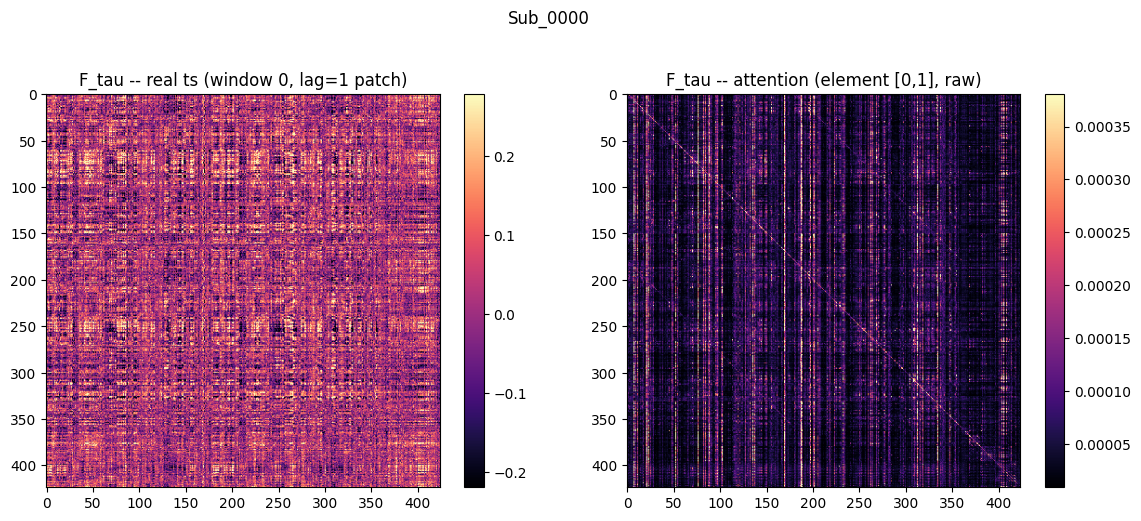

In [10]:
sub_res = asym_results[0]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, mat, title in zip(axes[:2], [sub_res["ftau_real"], sub_res["ftau_attn"]],
                           ["F_tau -- real ts (window 0, lag=1 patch)", "F_tau -- attention (element [0,1], raw)"]):
    v_lo, v_hi = np.percentile(mat, 1), np.percentile(mat, 99)
    im = ax.imshow(mat, cmap="magma", vmin=v_lo, vmax=v_hi)
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046)

# axes[2].scatter(sub_res["ftau_real"].ravel(), sub_res["ftau_attn"].ravel(), s=2, alpha=0.3)
# axes[2].set_xlabel("F_tau (real ts, window 0)")
# axes[2].set_ylabel("F_tau (attention, raw)")
# axes[2].set_title(f"{sub_res['subject_id']}: r = {sub_res['r_ftau']:.3f}")

fig.suptitle(sub_res["subject_id"], y=1.03)
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "ftau_real_vs_attention_matrices.png"), dpi=130, bbox_inches="tight")
plt.show()

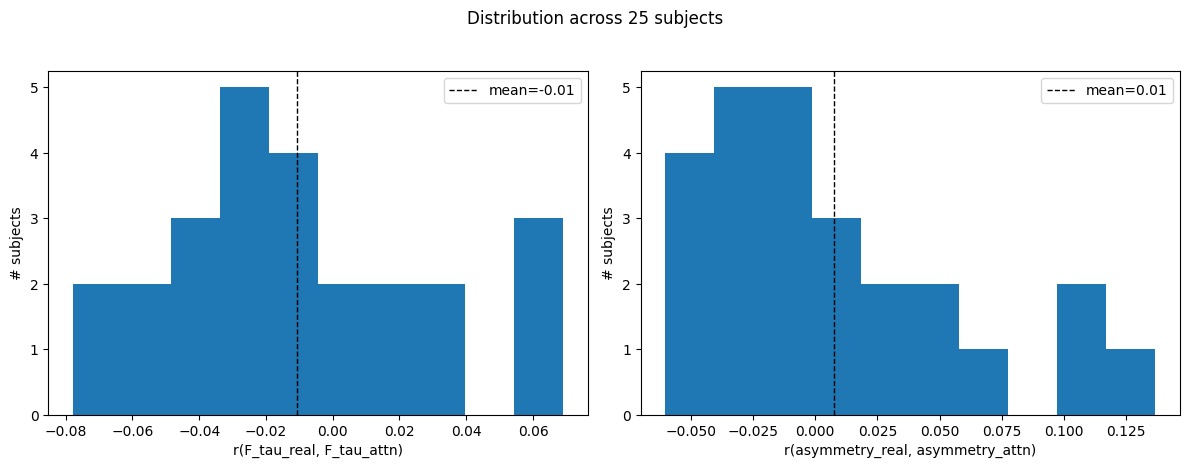

In [11]:
r_ftau_vals = np.array([r["r_ftau"] for r in asym_results])
r_asym_vals = np.array([r["r_asymmetry"] for r in asym_results])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, vals, label in zip(axes, [r_ftau_vals, r_asym_vals],
                           ["r(F_tau_real, F_tau_attn)", "r(asymmetry_real, asymmetry_attn)"]):
    ax.hist(vals, bins=min(10, len(vals)), color="tab:blue")
    ax.axvline(vals.mean(), color="black", linestyle="--", linewidth=1, label=f"mean={vals.mean():.2f}")
    ax.set_xlabel(label)
    ax.set_ylabel("# subjects")
    ax.legend()

fig.suptitle(f"Distribution across {len(asym_results)} subjects", y=1.03)
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "ftau_correlation_distributions.png"), dpi=130, bbox_inches="tight")
plt.show()

### Real F_tau (window 0) across increasing tau

Sanity check before comparing against attention at a single lag: how does the real-ts
shifted FC `F_tau(t, t+tau)` itself change as `tau` grows? Five increasing lags, evenly
spaced up to the actual comparison lag -- the last panel (`tau=tau_trs`) is exactly the
`F_tau_real` used above and in the rest of this section.

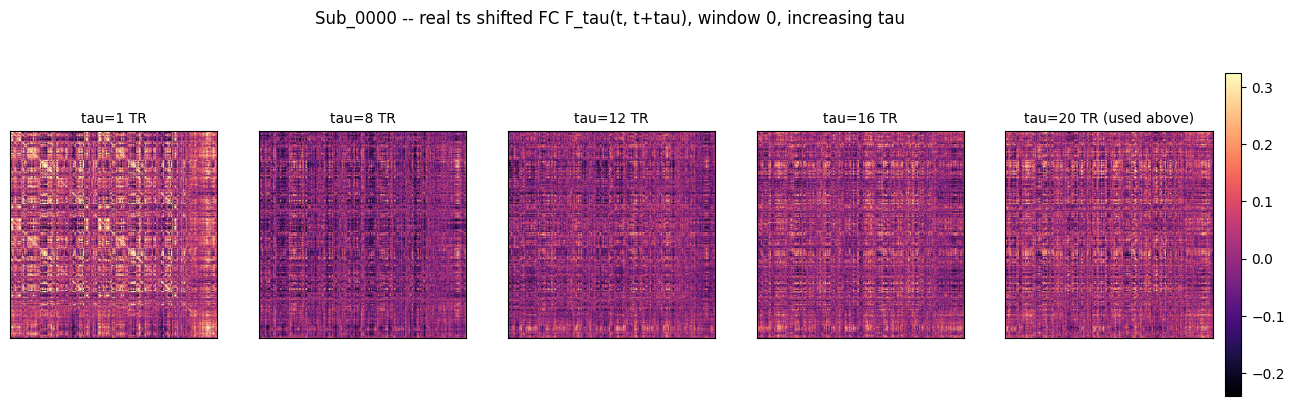

In [12]:
ts0 = window0_ts(subjects[0]["raw_ts"])
taus_trs = sorted({max(1, int(round(tau_trs * f))) for f in [0, 0.4, 0.6, 0.8, 1.0]})
shifted_fcs = [lagged_fc(ts0, tau=t) for t in taus_trs]

all_vals = np.concatenate([m.ravel() for m in shifted_fcs])
v_lo, v_hi = np.percentile(all_vals, 1), np.percentile(all_vals, 99)

fig, axes = plt.subplots(1, len(taus_trs), figsize=(3.2 * len(taus_trs), 4.2))
for ax, t, mat in zip(axes, taus_trs, shifted_fcs):
    im = ax.imshow(mat, cmap="magma", vmin=v_lo, vmax=v_hi)
    ax.set_title(f"tau={t} TR" + (" (used above)" if t == tau_trs else ""), fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])

fig.colorbar(im, ax=axes, fraction=0.02, pad=0.01)
fig.suptitle(f"{subjects[0]['subject_id']} -- real ts shifted FC F_tau(t, t+tau), window 0, increasing tau", y=1.03)
fig.savefig(os.path.join(FIGURES_DIR, "ftau_real_increasing_tau.png"), dpi=130, bbox_inches="tight")
plt.show()

## Part 3 -- FCD: functional connectivity dynamics, real ts vs. attention

FCD (Hansen et al., 2015, NeuroImage) captures the *switching* structure of FC over
time in a single time x time matrix: `FCD(t1, t2)` is the Pearson correlation between
two windowed-FC snapshots, `FC(t1)` and `FC(t2)` (using the upper triangle, since FC is
symmetric).

Both sides here are forced into exactly `num_patches=10` non-overlapping windows -- one
per BrainLM time patch (`timepoint_patching_size` TRs each) within window 0:

- **Real ts**: `FC(t)` = Pearson correlation of the real BOLD time series restricted to
  patch `t`'s `timepoint_patching_size`-TR slice of window 0 -- 10 snapshots, each from
  only 20 timepoints (noisy, but it's the finest granularity the model's own
  tokenization allows for a fair, matched comparison).
- **Attention**: `FC(t)` = the same-time (`tau=0`) diagonal block `attn_4d[:, t, :, t]`
  of the full attention matrix -- the 10 `[num_regions, num_regions]` blocks running
  down the block-grid diagonal introduced in Part 1. Unlike real FC these aren't
  symmetric, so the full flattened matrix is used instead of just the upper triangle
  (same convention used for F_tau/FDC elsewhere in this notebook).

In [13]:
np.shape(ts)

(424, 200)

In [14]:
def windowed_fc(ts, patch_size, num_patches):
    """num_patches Pearson FC matrices, one per non-overlapping patch_size-timepoint
    slice of ts [num_regions, T]."""
    return [np.corrcoef(ts[:, t * patch_size:(t + 1) * patch_size]) for t in range(num_patches)]

def attn_diagonal_fcs(attn_no_cls, num_regions, num_patches):
    """The num_patches same-time (tau=0) [num_regions, num_regions] diagonal blocks of
    the full attention matrix -- attention's analog of per-window FC(t)."""
    attn_4d = attn_no_cls.reshape(num_regions, num_patches, num_regions, num_patches)
    return [attn_4d[:, t, :, t] for t in range(num_patches)]

def fcd_matrix(fc_list, symmetric):
    """FCD(t1, t2) = Pearson correlation between two FC(t) snapshots (Hansen et al.,
    2015): the upper triangle when FC is symmetric (real ts), or the full flattened
    matrix when it isn't (attention)."""
    if symmetric:
        iu_local = np.triu_indices(fc_list[0].shape[0], k=1)
        vecs = np.stack([fc[iu_local] for fc in fc_list])
    else:
        vecs = np.stack([fc.ravel() for fc in fc_list])
    return np.corrcoef(vecs)

patch_size = config.timepoint_patching_size
iu_fcd = np.triu_indices(num_patches, k=1)

fcd_results = []
for s in subjects:
    ts = window0_ts(s["raw_ts"])
    fc_list_real = windowed_fc(ts, patch_size, num_patches)
    fc_list_attn = attn_diagonal_fcs(s["attn_no_cls"], num_regions, num_patches)

    fcd_real = fcd_matrix(fc_list_real, symmetric=True)
    fcd_attn = fcd_matrix(fc_list_attn, symmetric=False)

    r_fcd = np.corrcoef(fcd_real[iu_fcd], fcd_attn[iu_fcd])[0, 1]

    fcd_results.append({"subject_id": s["subject_id"], "fcd_real": fcd_real, "fcd_attn": fcd_attn, "r_fcd": r_fcd})
    print(f"{s['subject_id']}: r(FCD_real, FCD_attn) = {r_fcd:.4f}")

Sub_0000: r(FCD_real, FCD_attn) = -0.2083
Sub_0001: r(FCD_real, FCD_attn) = -0.2505
Sub_0002: r(FCD_real, FCD_attn) = 0.4651
Sub_0004: r(FCD_real, FCD_attn) = -0.3260
Sub_0005: r(FCD_real, FCD_attn) = 0.5979
Sub_0006: r(FCD_real, FCD_attn) = 0.0447
Sub_0007: r(FCD_real, FCD_attn) = -0.1929
Sub_0008: r(FCD_real, FCD_attn) = -0.3040


Sub_0009: r(FCD_real, FCD_attn) = -0.2388
Sub_0010: r(FCD_real, FCD_attn) = -0.3168
Sub_0011: r(FCD_real, FCD_attn) = 0.0949
Sub_0012: r(FCD_real, FCD_attn) = -0.2808
Sub_0013: r(FCD_real, FCD_attn) = -0.2369
Sub_0014: r(FCD_real, FCD_attn) = -0.2341
Sub_0015: r(FCD_real, FCD_attn) = -0.0644
Sub_0016: r(FCD_real, FCD_attn) = -0.0586


Sub_0017: r(FCD_real, FCD_attn) = 0.0756
Sub_0018: r(FCD_real, FCD_attn) = 0.1529
Sub_0019: r(FCD_real, FCD_attn) = -0.4231
Sub_0020: r(FCD_real, FCD_attn) = -0.2304
Sub_0021: r(FCD_real, FCD_attn) = -0.2350
Sub_0022: r(FCD_real, FCD_attn) = -0.2306
Sub_0023: r(FCD_real, FCD_attn) = -0.3446
Sub_0024: r(FCD_real, FCD_attn) = -0.2726


Sub_0025: r(FCD_real, FCD_attn) = -0.0908


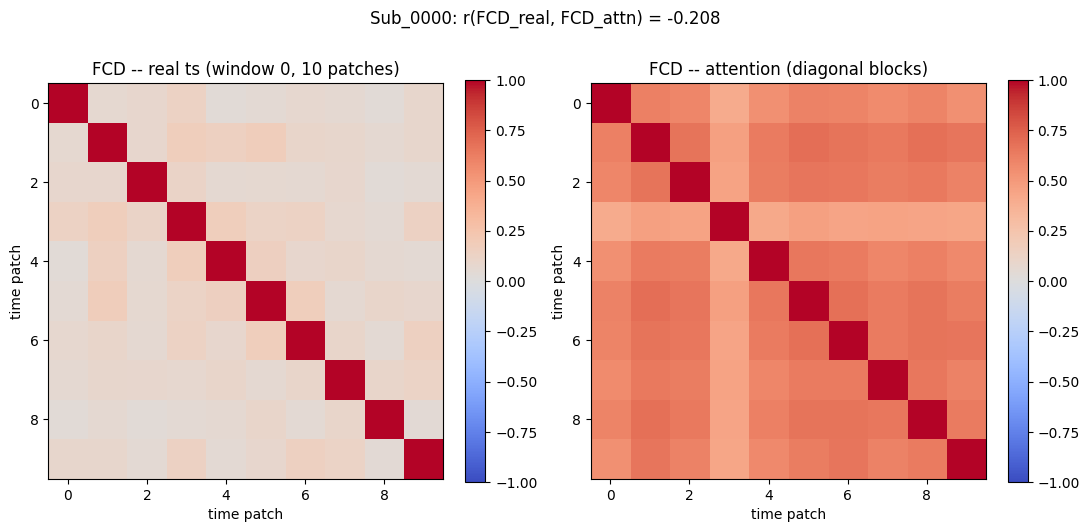

In [15]:
res = fcd_results[0]
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

im0 = axes[0].imshow(res["fcd_real"], cmap="coolwarm", vmin=-1, vmax=1)
axes[0].set_title("FCD -- real ts (window 0, 10 patches)")
axes[0].set_xlabel("time patch")
axes[0].set_ylabel("time patch")
fig.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(res["fcd_attn"], cmap="coolwarm", vmin=-1, vmax=1)
axes[1].set_title("FCD -- attention (diagonal blocks)")
axes[1].set_xlabel("time patch")
axes[1].set_ylabel("time patch")
fig.colorbar(im1, ax=axes[1], fraction=0.046)

fig.suptitle(f"{res['subject_id']}: r(FCD_real, FCD_attn) = {res['r_fcd']:.3f}", y=1.03)
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "fcd_real_vs_attention.png"), dpi=130, bbox_inches="tight")
plt.show()

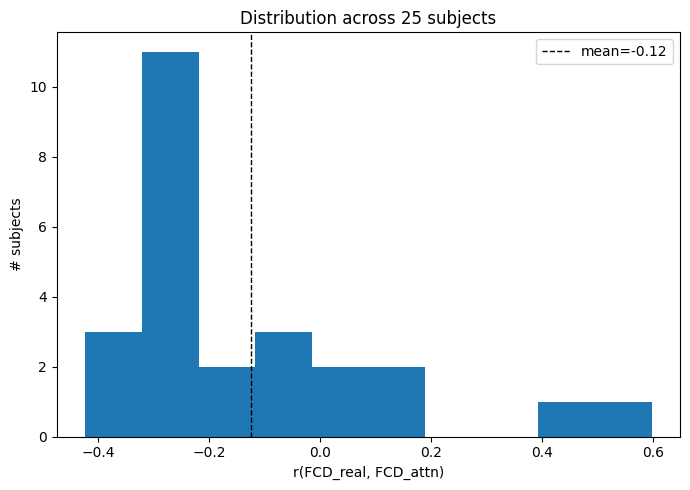

In [16]:
r_fcd_vals = np.array([r["r_fcd"] for r in fcd_results])

fig, ax = plt.subplots(1, 1, figsize=(7, 5))
ax.hist(r_fcd_vals, bins=min(10, len(r_fcd_vals)), color="tab:blue")
ax.axvline(r_fcd_vals.mean(), color="black", linestyle="--", linewidth=1, label=f"mean={r_fcd_vals.mean():.2f}")
ax.set_xlabel("r(FCD_real, FCD_attn)")
ax.set_ylabel("# subjects")
ax.set_title(f"Distribution across {len(fcd_results)} subjects")
ax.legend()

fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "fcd_correlation_distribution.png"), dpi=130, bbox_inches="tight")
plt.show()

## Part 4 -- Aggregate F_tau vs. FDC across multiple lags (averaged over time)

Hypothesis: averaging every off-diagonal attention block at a fixed lag `k` patches --
`compute_ftau(attn_no_cls, ..., tau=k)`, i.e. `mean_t attn_4d[:, t, :, t+k]` -- is the
attention analog of the real lagged FC computed on the full window-0 series at the
matching lag, `lagged_fc(ts, tau=k*patch_size)`. Averaging over `t` removes the temporal
dimension entirely, so this can only test whether the lag-`k` *structure* matches in
aggregate -- not whether it holds patch-by-patch (that's Part 5).

We check the smallest lag the model's own tokenization can express first (`k=1` patch =
20 TR -- the same `tau_trs` used in Part 2), then repeat for `k=2,3,4` (40/60/80 TR) to
see whether the correspondence holds or decays as the lag grows.

In [17]:
LAG_PATCHES_LIST = [1, 2, 3, 4]  # 20, 40, 60, 80 TR

agg_results = []
for lag in LAG_PATCHES_LIST:
    for s in subjects:
        ts = window0_ts(s["raw_ts"])
        ftau_attn_agg = compute_ftau(s["attn_no_cls"], num_regions, num_patches, tau=lag)
        ftau_real_agg = lagged_fc(ts, tau=lag * patch_size)
        r = np.corrcoef(ftau_attn_agg.ravel(), ftau_real_agg.ravel())[0, 1]
        agg_results.append({
            "subject_id": s["subject_id"], "lag_patches": lag, "lag_tr": lag * patch_size, "r_agg": r,
        })

for lag in LAG_PATCHES_LIST:
    vals = np.array([r["r_agg"] for r in agg_results if r["lag_patches"] == lag])
    print(f"lag={lag} patch(es) ({lag * patch_size} TR): r(FDC_real, F_tau_attn_avg) "
          f"mean={vals.mean():.4f}, median={np.median(vals):.4f}, std={vals.std():.4f}")

lag=1 patch(es) (20 TR): r(FDC_real, F_tau_attn_avg) mean=-0.0192, median=-0.0230, std=0.0459
lag=2 patch(es) (40 TR): r(FDC_real, F_tau_attn_avg) mean=-0.0270, median=-0.0222, std=0.0464
lag=3 patch(es) (60 TR): r(FDC_real, F_tau_attn_avg) mean=-0.0022, median=-0.0051, std=0.0449
lag=4 patch(es) (80 TR): r(FDC_real, F_tau_attn_avg) mean=-0.0155, median=-0.0202, std=0.0399


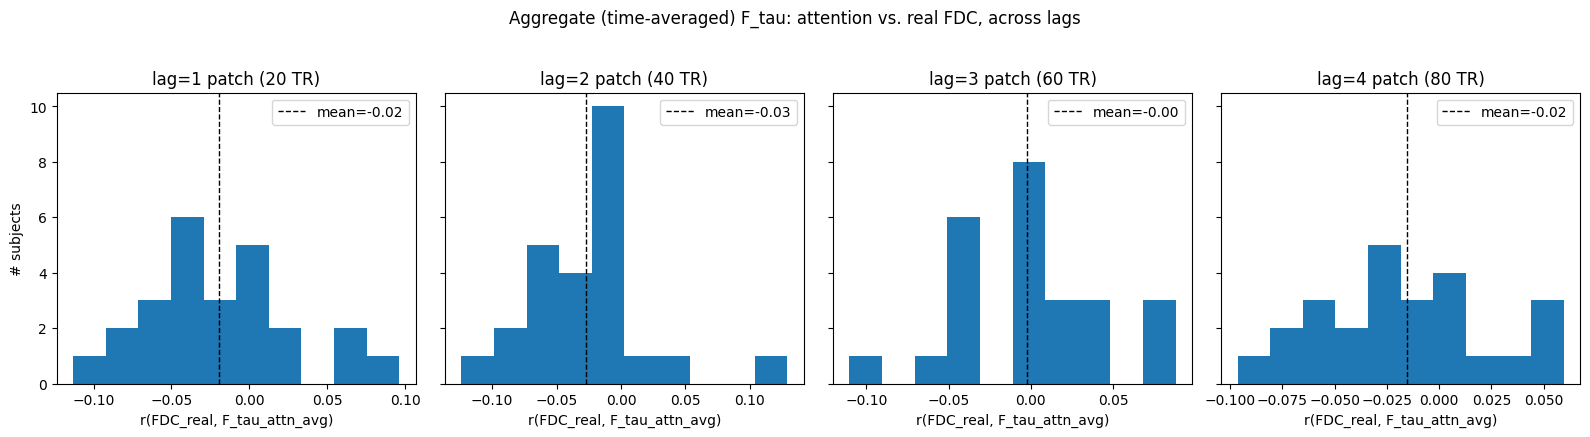

In [18]:
fig, axes = plt.subplots(1, len(LAG_PATCHES_LIST), figsize=(4 * len(LAG_PATCHES_LIST), 4.2), sharey=True)
for ax, lag in zip(axes, LAG_PATCHES_LIST):
    vals = np.array([r["r_agg"] for r in agg_results if r["lag_patches"] == lag])
    ax.hist(vals, bins=min(10, len(vals)), color="tab:blue")
    ax.axvline(vals.mean(), color="black", linestyle="--", linewidth=1, label=f"mean={vals.mean():.2f}")
    ax.set_title(f"lag={lag} patch ({lag * patch_size} TR)")
    ax.set_xlabel("r(FDC_real, F_tau_attn_avg)")
    ax.legend()
axes[0].set_ylabel("# subjects")

fig.suptitle("Aggregate (time-averaged) F_tau: attention vs. real FDC, across lags", y=1.03)
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "ftau_aggregate_vs_fdc_by_lag.png"), dpi=130, bbox_inches="tight")
plt.show()

## Part 5 -- Per-patch F_tau: does the lag-k structure hold block by block?

Part 4 averaged over every valid source patch `t`, which can hide patch-by-patch
disagreement even when the aggregate correlation looks good. Here each `(t, t+k)` block
is kept separate instead: for lag `k` patches, `attn_4d[:, t, :, t+k]` (t = 0 ..
`num_patches-k-1`) is compared against the matching piece of the real time series -- the
correlation between region i's patch-`t` series and region j's patch-`(t+k)` series.

`lagged_fc_by_patch` below computes exactly that: it uses the *same* whole-window
(window-0) centering/normalization as `lagged_fc` -- not a separate per-patch
normalization -- and returns the individual `(t, t+k)` terms of `lagged_fc`'s sum
instead of averaging them. That keeps Parts 4 and 5 exactly consistent: `mean(
lagged_fc_by_patch(ts, patch_size, num_patches, k), axis=0) == lagged_fc(ts,
tau=k*patch_size)` (verified numerically to ~1e-15), and on the attention side
`compute_ftau(..., tau=k)` is already `mean_t attn_4d[:, t, :, t+k]` by construction --
so Part 5's per-block values are exactly what Part 4 averages over.

We start with `k=1` (20 TR) and repeat for `k=2,3,4`, giving a within-subject
distribution of `num_patches - k` r-values per lag, plus the pooled distribution across
all subjects and valid `t`.

In [19]:
def lagged_fc_by_patch(ts, patch_size, num_patches, lag_patches):
    """Same global (whole-window) centering/normalization as lagged_fc, but returns the
    individual per-source-patch [num_regions, num_regions] blocks separately instead of
    averaging them: block t is corr(region i's patch-t series, region j's
    patch-(t+lag_patches) series). mean(blocks, axis=0) == lagged_fc(ts,
    tau=lag_patches*patch_size)."""
    ts_c = ts - ts.mean(axis=1, keepdims=True)
    std = np.sqrt(np.mean(ts_c ** 2, axis=1))
    std[std <= 0] = 1e-12
    norm = np.outer(std, std)

    blocks = []
    for t in range(num_patches - lag_patches):
        src = ts_c[:, t * patch_size:(t + 1) * patch_size]
        tgt = ts_c[:, (t + lag_patches) * patch_size:(t + lag_patches + 1) * patch_size]
        cov = src @ tgt.T / patch_size
        blocks.append(cov / norm)
    return blocks


per_block_results = []
for lag in LAG_PATCHES_LIST:
    for s in subjects:
        ts = window0_ts(s["raw_ts"])
        real_blocks = lagged_fc_by_patch(ts, patch_size, num_patches, lag)
        for t, real_block in enumerate(real_blocks):
            attn_block = raw_ftau_block(s["attn_no_cls"], num_regions, num_patches, t, t + lag)
            r = np.corrcoef(real_block.ravel(), attn_block.ravel())[0, 1]
            per_block_results.append({
                "subject_id": s["subject_id"], "lag_patches": lag, "t_src": t, "t_tgt": t + lag, "r_block": r,
            })

print(f"{len(per_block_results)} (subject, lag, t) comparisons total")
for lag in LAG_PATCHES_LIST:
    vals = np.array([r["r_block"] for r in per_block_results if r["lag_patches"] == lag])
    print(f"lag={lag} patch(es) ({lag * patch_size} TR): r(F_tau_real_block, F_tau_attn_block) "
          f"mean={vals.mean():.4f}, median={np.median(vals):.4f}, std={vals.std():.4f}")

750 (subject, lag, t) comparisons total
lag=1 patch(es) (20 TR): r(F_tau_real_block, F_tau_attn_block) mean=-0.0216, median=-0.0272, std=0.0405
lag=2 patch(es) (40 TR): r(F_tau_real_block, F_tau_attn_block) mean=-0.0239, median=-0.0247, std=0.0264
lag=3 patch(es) (60 TR): r(F_tau_real_block, F_tau_attn_block) mean=-0.0195, median=-0.0195, std=0.0259
lag=4 patch(es) (80 TR): r(F_tau_real_block, F_tau_attn_block) mean=-0.0172, median=-0.0193, std=0.0278


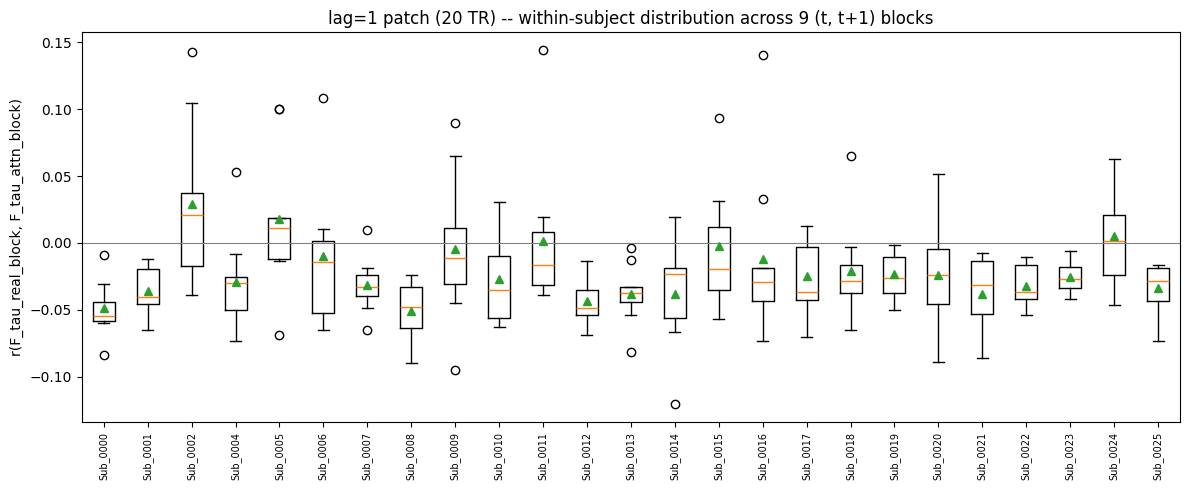

In [20]:
sub_ids = [s["subject_id"] for s in subjects]
lag1_by_subject = [
    [r["r_block"] for r in per_block_results if r["lag_patches"] == 1 and r["subject_id"] == sid]
    for sid in sub_ids
]

fig, ax = plt.subplots(1, 1, figsize=(12, 5))
ax.boxplot(lag1_by_subject, showmeans=True)
ax.set_xticks(range(1, len(sub_ids) + 1))
ax.set_xticklabels(sub_ids, rotation=90, fontsize=7)
ax.axhline(0, color="gray", linewidth=0.8)
ax.set_ylabel("r(F_tau_real_block, F_tau_attn_block)")
ax.set_title(f"lag=1 patch (20 TR) -- within-subject distribution across {num_patches - 1} (t, t+1) blocks")

fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "ftau_per_block_within_subject_lag1.png"), dpi=130, bbox_inches="tight")
plt.show()

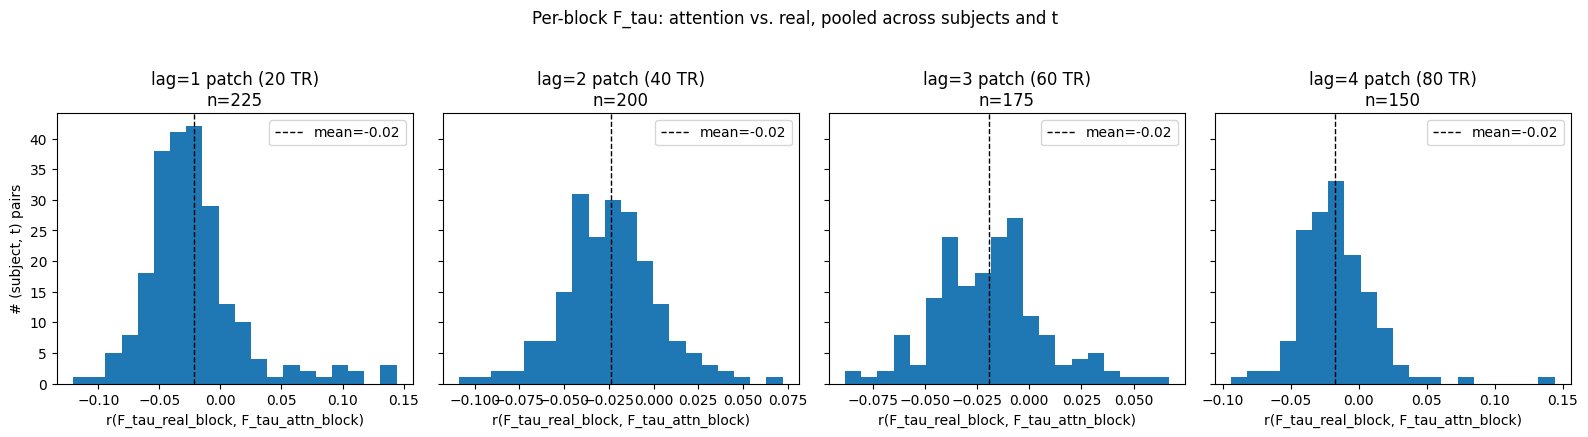

In [21]:
fig, axes = plt.subplots(1, len(LAG_PATCHES_LIST), figsize=(4 * len(LAG_PATCHES_LIST), 4.2), sharey=True)
for ax, lag in zip(axes, LAG_PATCHES_LIST):
    vals = np.array([r["r_block"] for r in per_block_results if r["lag_patches"] == lag])
    ax.hist(vals, bins=20, color="tab:blue")
    ax.axvline(vals.mean(), color="black", linestyle="--", linewidth=1, label=f"mean={vals.mean():.2f}")
    ax.set_title(f"lag={lag} patch ({lag * patch_size} TR)\nn={len(vals)}")
    ax.set_xlabel("r(F_tau_real_block, F_tau_attn_block)")
    ax.legend()
axes[0].set_ylabel("# (subject, t) pairs")

fig.suptitle("Per-block F_tau: attention vs. real, pooled across subjects and t", y=1.03)
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "ftau_per_block_pooled_by_lag.png"), dpi=130, bbox_inches="tight")
plt.show()